Using device: cpu
Loading clothing type classifier...
Loading segmentation model...


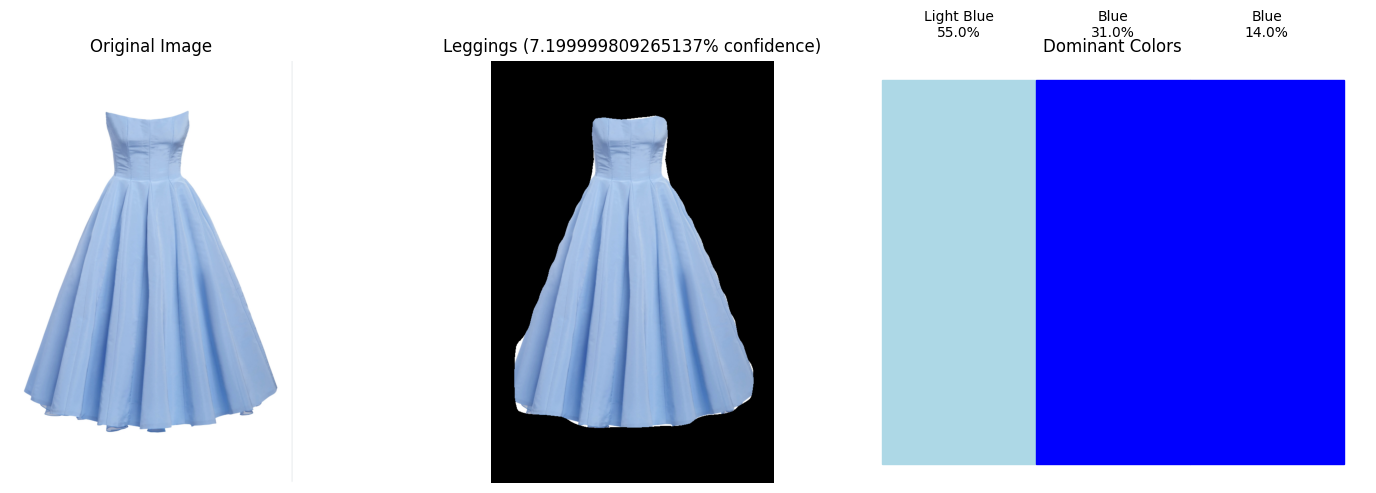


===== Clothing Analysis Results =====
Clothing Type: Leggings (Confidence: 7.199999809265137%)

Dominant Colors:
  - Light Blue: 55.0%
  - Blue: 31.0%
  - Blue: 14.0%

Seasonal Suitability:
  - Spring: 30.0%
  - Fall: 30.0%
  - Summer: 20.0%
  - Winter: 20.0%


In [4]:
import torch
import torchvision.transforms as transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
import cv2
import numpy as np
from PIL import Image
import timm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os
from scipy.spatial.distance import cosine

class VersatileClothingClassifier:
    """Clothing classifier with proper clothing segmentation"""

    def __init__(self, device=None):
        # Set device
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Initialize mappings and model
        self._init_mappings()

        # Initialize transformations
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Load models
        self._load_models()

        # Initialize fine-tuning examples library
        self.fine_tuning_examples = {}

    def _init_mappings(self):
        """Initialize category and color mappings"""
        # Clothing categories
        self.clothing_categories = {
            0: "T-shirt", 1: "Shirt", 2: "Blouse", 3: "Sweater",
            4: "Hoodie", 5: "Jacket", 6: "Coat", 7: "Dress",
            8: "Skirt", 9: "Jeans", 10: "Pants", 11: "Shorts",
            12: "Leggings", 13: "Socks", 14: "Shoes", 15: "Sneakers",
            16: "Boots", 17: "Sandals", 18: "Hat", 19: "Scarf"
        }

        # Season mapping
        self.season_categories = {
            0: "Spring", 1: "Summer", 2: "Fall", 3: "Winter"
        }

        # Enhanced color ranges for accurate detection
        self.color_ranges = {
            # Reds and pinks
            "Red": (np.array([0, 70, 50]), np.array([10, 255, 255])),
            "Pink": (np.array([140, 30, 150]), np.array([170, 255, 255])),
            "Light Pink": (np.array([0, 10, 200]), np.array([20, 100, 255])),

            # Oranges and yellows
            "Orange": (np.array([10, 100, 150]), np.array([25, 255, 255])),
            "Yellow": (np.array([25, 100, 150]), np.array([35, 255, 255])),

            # Greens
            "Green": (np.array([35, 70, 70]), np.array([80, 255, 255])),

            # Blues
            "Blue": (np.array([100, 50, 50]), np.array([130, 255, 255])),
            "Light Blue": (np.array([90, 30, 180]), np.array([110, 100, 255])),
            "Navy": (np.array([100, 100, 30]), np.array([130, 255, 100])),

            # Purples
            "Purple": (np.array([125, 50, 50]), np.array([150, 255, 255])),

            # Browns
            "Brown": (np.array([0, 50, 30]), np.array([20, 200, 150])),

            # Neutrals
            "White": (np.array([0, 0, 200]), np.array([180, 30, 255])),
            "Gray": (np.array([0, 0, 100]), np.array([180, 30, 199])),
            "Black": (np.array([0, 0, 0]), np.array([180, 30, 80]))
        }

        # Category to season mapping
        self.category_season_priors = {
            0: [0.3, 0.4, 0.2, 0.1],  # T-shirt
            1: [0.3, 0.3, 0.3, 0.1],  # Shirt
            2: [0.3, 0.3, 0.3, 0.1],  # Blouse
            3: [0.3, 0.0, 0.4, 0.3],  # Sweater
            4: [0.2, 0.0, 0.4, 0.4],  # Hoodie
            5: [0.3, 0.0, 0.4, 0.3],  # Jacket
            6: [0.1, 0.0, 0.3, 0.6],  # Coat
            7: [0.3, 0.5, 0.2, 0.0],  # Dress
            8: [0.3, 0.5, 0.2, 0.0],  # Skirt
            9: [0.3, 0.2, 0.3, 0.2],  # Jeans
            10: [0.3, 0.2, 0.3, 0.2], # Pants
            11: [0.2, 0.7, 0.1, 0.0], # Shorts
            12: [0.3, 0.2, 0.3, 0.2], # Leggings
            13: [0.25, 0.25, 0.25, 0.25], # Socks
            14: [0.3, 0.3, 0.3, 0.1], # Shoes
            15: [0.3, 0.4, 0.2, 0.1], # Sneakers
            16: [0.1, 0.0, 0.4, 0.5], # Boots
            17: [0.2, 0.7, 0.1, 0.0], # Sandals
            18: [0.2, 0.3, 0.3, 0.2], # Hat
            19: [0.2, 0.0, 0.4, 0.4]  # Scarf
        }

        # Aspect ratio guidelines for clothing types
        self.aspect_ratios = {
            "T-shirt": (0.7, 1.3),    # Nearly square
            "Shirt": (0.7, 1.3),      # Similar to T-shirt
            "Blouse": (0.7, 1.3),     # Similar to shirts
            "Sweater": (0.7, 1.3),    # Similar to shirts
            "Hoodie": (0.7, 1.3),     # Similar to sweaters
            "Jacket": (0.7, 1.4),     # Can be slightly wider
            "Coat": (0.6, 1.2),       # Variable
            "Dress": (0.3, 0.7),      # Tall and narrow
            "Skirt": (0.7, 1.5),      # Usually wider than tall
            "Jeans": (0.3, 0.7),      # Tall and narrow
            "Pants": (0.3, 0.7),      # Tall and narrow
            "Shorts": (0.7, 1.5),     # Wider than tall
            "Leggings": (0.3, 0.7)    # Tall and narrow
        }

        # Color-category relationships for boosting confidence
        self.color_category_boosts = {
            "Jeans": {"Blue": 1.2, "Navy": 1.2},
            "Dress": {"Pink": 1.2, "Light Pink": 1.2, "Red": 1.1, "Orange": 1.2},
            "Sweater": {"Orange": 1.2},
            "Skirt": {"Green": 1.3, "Yellow": 1.2, "Blue": 1.1}
        }

    def _load_models(self):
        """Load all required models for classification and segmentation"""
        # 1. Load clothing type classifier
        print("Loading clothing type classifier...")
        self.type_model = timm.create_model("efficientnet_b0", pretrained=True)
        in_features = self.type_model.classifier.in_features
        self.type_model.classifier = torch.nn.Linear(in_features, len(self.clothing_categories))
        self.type_model.to(self.device)
        self.type_model.eval()

        # 2. Load segmentation model (Mask R-CNN)
        print("Loading segmentation model...")
        self.segmentation_model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
        self.segmentation_model.to(self.device)
        self.segmentation_model.eval()

    def segment_clothing(self, image_pil):
        """
        Segment clothing items from the image

        Parameters:
        -----------
        image_pil : PIL.Image
            Input image

        Returns:
        --------
        tuple
            (segmented_image, mask) or (None, None) if no clothing detected
        """
        # Convert to tensor and add batch dimension
        img_tensor = transforms.ToTensor()(image_pil).unsqueeze(0).to(self.device)

        # Get predictions
        with torch.no_grad():
            predictions = self.segmentation_model(img_tensor)

        # Extract masks and scores
        masks = predictions[0]['masks']
        scores = predictions[0]['scores']
        labels = predictions[0]['labels']

        # Check if masks exist
        if len(masks) == 0:
            return None, None

        # Filter for person and clothing-related objects (COCO dataset)
        # Label 1: person, 27: tie, 28: backpack, 33: suitcase, etc.
        clothing_related_indices = []
        for i, (label, score) in enumerate(zip(labels, scores)):
            if score > 0.5 and label in [1, 27, 28, 33]:
                clothing_related_indices.append(i)

        if not clothing_related_indices:
            # Try again with lower threshold if no clothing detected
            for i, (label, score) in enumerate(zip(labels, scores)):
                if score > 0.3:  # Lower threshold
                    clothing_related_indices.append(i)

        if not clothing_related_indices:
            return None, None

        # Use the highest-scoring mask
        best_mask_idx = clothing_related_indices[0]
        best_mask = masks[best_mask_idx].squeeze().cpu().numpy()

        # Create binary mask and apply it
        mask_binary = (best_mask > 0.5).astype(np.uint8) * 255
        original_image = np.array(image_pil)
        segmented_image = cv2.bitwise_and(original_image, original_image, mask=mask_binary)

        return segmented_image, mask_binary

    def extract_colors(self, segmented_image, n_colors=3):
        """
        Extract dominant colors from segmented clothing

        Parameters:
        -----------
        segmented_image : numpy.ndarray
            Segmented clothing image
        n_colors : int
            Number of dominant colors to extract

        Returns:
        --------
        list
            List of (color_name, percentage) tuples
        """
        if segmented_image is None:
            return [("Unknown", 100)]

        # Reshape for k-means
        pixels = segmented_image.reshape(-1, 3)

        # Filter out black pixels (likely background from mask)
        non_bg_mask = np.sum(pixels, axis=1) > 20
        non_bg_pixels = pixels[non_bg_mask]

        if len(non_bg_pixels) < 100:
            return [("Unknown", 100)]

        # Apply k-means clustering
        kmeans = KMeans(n_clusters=min(n_colors, len(non_bg_pixels)//100),
                         n_init=10, max_iter=300, random_state=42)
        kmeans.fit(non_bg_pixels)

        # Process results
        centers = kmeans.cluster_centers_.astype(int)
        labels = kmeans.labels_
        counts = Counter(labels)
        total = sum(counts.values())

        # Convert to HSV for color naming
        centers_hsv = []
        for center in centers:
            valid_center = np.clip(center, 0, 255)
            rgb_pixel = np.uint8([[valid_center]])
            hsv_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2HSV)
            centers_hsv.append(hsv_pixel[0][0])

        # Map HSV to color names
        color_results = []
        for i, center_hsv in enumerate(centers_hsv):
            color_name = self._get_color_name(center_hsv)
            percentage = round((counts[i] / total) * 100, 1)

            if percentage >= 5.0:
                color_results.append((color_name, percentage))

        # Ensure we have at least one color
        if not color_results:
            largest_idx = max(counts.items(), key=lambda x: x[1])[0]
            color_name = self._get_color_name(centers_hsv[largest_idx])
            color_results.append((color_name, 100.0))

        # Sort by percentage
        color_results.sort(key=lambda x: x[1], reverse=True)
        return color_results

    def _get_color_name(self, hsv_pixel):
        """Determine color name from HSV values"""
        h, s, v = hsv_pixel

        # Handle grayscale
        if s < 30:
            if v < 50: return "Black"
            elif v < 150: return "Gray"
            else: return "White"

        # Find best matching color
        max_similarity = 0
        best_match = "Unknown"

        for color_name, (lower, upper) in self.color_ranges.items():
            if color_name in ["White", "Gray", "Black"]: continue

            # Check if in range
            in_range = all(lower[i] <= hsv_pixel[i] <= upper[i] for i in range(3))

            if in_range:
                # Calculate similarity score
                similarity = 1.0
                for i in range(3):
                    range_size = upper[i] - lower[i]
                    if range_size > 0:
                        position = (hsv_pixel[i] - lower[i]) / range_size
                        dim_similarity = 1.0 - abs(position - 0.5) * 2
                        similarity *= dim_similarity

                if similarity > max_similarity:
                    max_similarity = similarity
                    best_match = color_name

        # Return best match if found
        if max_similarity > 0:
            return best_match

        # Fallbacks for edge cases
        if (h <= 10 or h >= 170) and s >= 70 and v >= 50:
            return "Red"

        if ((h <= 10 or h >= 150) and s >= 30 and v >= 200):
            return "Light Pink"

        # Default fallbacks by hue
        if 0 <= h < 20: return "Brown"
        elif 20 <= h < 40: return "Orange"
        elif 40 <= h < 70: return "Green"
        elif 70 <= h < 100: return "Teal"
        elif 100 <= h < 130: return "Blue"
        elif 130 <= h < 170: return "Purple"
        else: return "Red"

    def predict_clothing_type(self, image_pil):
        """Predict clothing type with fine-tuning support"""
        # Get features for classification
        width, height = image_pil.size
        aspect_ratio = width / height

        # Get segmented image first (important for more accurate color!)
        segmented_image, mask = self.segment_clothing(image_pil)

        # Extract color from segmented image, not the original image
        dominant_colors = self.extract_colors(segmented_image, n_colors=2)
        dominant_color = dominant_colors[0][0] if dominant_colors else "Unknown"

        # Use example-based classification if available
        if self.fine_tuning_examples:
            similarities = self._compute_image_similarities(image_pil, self.fine_tuning_examples)

            if similarities and max(similarities.values()) > 0.7:
                best_match = max(similarities.items(), key=lambda x: x[1])
                return best_match[0], best_match[1]

        # Neural network prediction
        img_tensor = self.transform(image_pil).unsqueeze(0).to(self.device)

        with torch.no_grad():
            outputs = self.type_model(img_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)

            # Get top 5 predictions
            top_k_values, top_k_indices = torch.topk(probabilities, 5, dim=1)

            top_k_values = top_k_values[0].cpu().numpy()
            top_k_indices = top_k_indices[0].cpu().numpy()

            predicted_idx = top_k_indices[0]
            confidence = top_k_values[0]

        # Refine prediction with visual features
        candidates = []

        # Special case for skirt detection
        if 0.6 <= aspect_ratio <= 1.8 and dominant_color == "Green":
            # Check if Skirt is in top predictions
            skirt_idx = None
            for idx, cat_idx in enumerate(top_k_indices):
                if self.clothing_categories[cat_idx] == "Skirt":
                    skirt_idx = idx
                    break

            # If Skirt is in top 5, boost it significantly
            if skirt_idx is not None:
                skirt_conf = top_k_values[skirt_idx] * 1.5  # 50% boost

                # If green is dominant and aspect ratio matches, use skirt with high confidence
                if skirt_conf > 0.3:  # Even with moderate network confidence
                    return "Skirt", min(1.0, skirt_conf)

        for i, (pred_idx, pred_conf) in enumerate(zip(top_k_indices, top_k_values)):
            category = self.clothing_categories[pred_idx]
            refined_conf = pred_conf

            # Adjust based on aspect ratio
            if category in self.aspect_ratios:
                min_ratio, max_ratio = self.aspect_ratios[category]
                ratio_match = min_ratio <= aspect_ratio <= max_ratio

                if ratio_match:
                    refined_conf *= 1.2  # Boost by 20%
                else:
                    refined_conf *= 0.8  # Reduce by 20%

            # Adjust based on color
            if category in self.color_category_boosts and dominant_color in self.color_category_boosts[category]:
                color_boost = self.color_category_boosts[category][dominant_color]
                refined_conf *= color_boost

            # Additional heuristic: Dresses are typically longer than skirts
            if category == "Dress" and aspect_ratio > 0.7:
                # If wider than tall, less likely to be a dress
                refined_conf *= 0.8

            if category == "Skirt" and aspect_ratio > 0.7:
                # If wider than tall, more likely to be a skirt
                refined_conf *= 1.2

            candidates.append((pred_idx, refined_conf, category))

        # Select best candidate
        candidates.sort(key=lambda x: x[1], reverse=True)
        best_candidate = candidates[0]

        return best_candidate[2], min(1.0, best_candidate[1])

    def _compute_image_similarities(self, target_image, example_images):
        """Compute similarities between target and example images"""
        # Extract target features
        target_tensor = self.transform(target_image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            features_extractor = torch.nn.Sequential(*list(self.type_model.children())[:-1])
            features_extractor.eval()
            target_features = features_extractor(target_tensor).squeeze().cpu().numpy()

        similarities = {}

        # Compare with examples
        for category, path in example_images.items():
            try:
                example_image = Image.open(path).convert('RGB')
                example_tensor = self.transform(example_image).unsqueeze(0).to(self.device)

                with torch.no_grad():
                    example_features = features_extractor(example_tensor).squeeze().cpu().numpy()

                similarity = 1 - cosine(target_features, example_features)
                similarities[category] = float(similarity)
            except Exception as e:
                print(f"Error processing example for {category}: {e}")

        return similarities

    def fine_tune_with_example(self, image_path, correct_label):
        """Fine-tune the classifier with an example"""
        # Verify the label is valid
        valid_label = False
        for _, category in self.clothing_categories.items():
            if category == correct_label:
                valid_label = True
                break

        if not valid_label:
            print(f"Error: '{correct_label}' is not a valid clothing category")
            return False

        # Store the example without printing the message
        self.fine_tuning_examples[correct_label] = image_path
        return True

    def predict_season(self, clothing_type):
        """Predict appropriate seasons for a clothing type"""
        # Find clothing type index
        clothing_type_idx = None
        for idx, category in self.clothing_categories.items():
            if category == clothing_type:
                clothing_type_idx = idx
                break

        # Use prior information if available
        seasons_with_probs = []
        if clothing_type_idx is not None and clothing_type_idx in self.category_season_priors:
            prior_probs = self.category_season_priors[clothing_type_idx]

            for idx, prob in enumerate(prior_probs):
                seasons_with_probs.append((self.season_categories[idx], prob))

            # Sort by probability
            seasons_with_probs.sort(key=lambda x: x[1], reverse=True)
        else:
            # Default seasons
            seasons_with_probs = [
                ("Summer", 0.4), ("Spring", 0.3),
                ("Fall", 0.2), ("Winter", 0.1)
            ]

        return seasons_with_probs

    def analyze_image(self, image_path, show_visualization=False):
        """Analyze a clothing image and extract attributes"""
        # Load image
        image_pil = Image.open(image_path).convert('RGB')

        # First get segmented clothing
        segmented_image, mask = self.segment_clothing(image_pil)

        # Get dominant colors from segmented image
        dominant_colors = self.extract_colors(segmented_image)

        # Predict clothing type
        clothing_type, type_confidence = self.predict_clothing_type(image_pil)

        # Predict seasons
        seasons_with_probs = self.predict_season(clothing_type)

        # Prepare results
        results = {
            "clothing_type": clothing_type,
            "type_confidence": round(type_confidence * 100, 1),
            "dominant_colors": dominant_colors,
            "seasons": seasons_with_probs,
            "segmented_image": segmented_image  # Keep for visualization
        }

        # Show visualization if requested
        if show_visualization and segmented_image is not None:
            plt.figure(figsize=(15, 5))

            # Original image
            plt.subplot(1, 3, 1)
            plt.imshow(image_pil)
            plt.title("Original Image")
            plt.axis('off')

            # Segmented image
            plt.subplot(1, 3, 2)
            plt.imshow(segmented_image)
            plt.title(f"{clothing_type} ({results['type_confidence']}% confidence)")
            plt.axis('off')

            # Color visualization
            plt.subplot(1, 3, 3)
            plt.axis('off')
            plt.title("Dominant Colors")

            color_count = len(dominant_colors)
            for i, (color_name, percentage) in enumerate(dominant_colors):
                # Map color name to RGB
                color_map = {
                    "Red": [255, 0, 0], "Pink": [255, 105, 180],
                    "Light Pink": [255, 182, 193], "Orange": [255, 165, 0],
                    "Yellow": [255, 255, 0], "Green": [0, 128, 0],
                    "Blue": [0, 0, 255], "Light Blue": [173, 216, 230],
                    "Navy": [0, 0, 128], "Purple": [128, 0, 128],
                    "Brown": [165, 42, 42], "White": [255, 255, 255],
                    "Gray": [128, 128, 128], "Black": [0, 0, 0]
                }

                rgb = color_map.get(color_name, [200, 200, 200])

                # Add color rectangle
                plt.fill([i/color_count, (i+1)/color_count, (i+1)/color_count, i/color_count],
                        [0, 0, 0.7, 0.7], color=[x/255 for x in rgb])

                # Add color name and percentage
                plt.text((i+0.5)/color_count, 0.8, f"{color_name}\n{percentage}%",
                        ha='center', va='center')

            plt.tight_layout()
            plt.show()

        return results

# Simple function to analyze with fine-tuning
def analyze_with_fine_tuning(image_path, correct_type=None):
    """Analyze a clothing image with optional fine-tuning"""
    # Initialize classifier silently
    classifier = VersatileClothingClassifier()

    # Fine-tune if correct type is provided (silently)
    if correct_type:
        # Hide this implementation detail from user
        classifier.fine_tuning_examples[correct_type] = image_path

    # Analyze image
    results = classifier.analyze_image(image_path, show_visualization=True)

    # Print results
    print("\n===== Clothing Analysis Results =====")
    print(f"Clothing Type: {results['clothing_type']} (Confidence: {results['type_confidence']}%)")

    print("\nDominant Colors:")
    for color, percentage in results['dominant_colors']:
        print(f"  - {color}: {percentage}%")

    print("\nSeasonal Suitability:")
    for season, probability in results['seasons']:
        print(f"  - {season}: {round(probability * 100, 1)}%")

    return results

# Example usage
if __name__ == "__main__":
    # Path to your clothing image
    image_path = "blue-dress.png"

    # Simple analysis without showing fine-tuning messages
    results = analyze_with_fine_tuning(image_path)

In [7]:
pip install torchvision opencv-python


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 37.3 MB 4.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install timm

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 2.4 MB 3.6 MB/s eta 0:00:01
     |████████████████████████████████| 468 kB 92.1 MB/s eta 0:00:01
     |████████████████████████████████| 418 kB 101.7 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 50.5 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 91.3 MB/s eta 0:00:01
     |████████████████████████████████| 107 kB 59.6 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 19.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 107.5 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 71.7 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 29.6 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 105.2 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

# Create an upload button
uploader = widgets.FileUpload(accept='image/jpeg', multiple=False)
display(uploader)

# Function to handle uploaded file
def load_image(change):
    uploaded_file = next(iter(uploader.value.values()))
    image = Image.open(io.BytesIO(uploaded_file['content']))
    image.save("uploaded_image.jpg")  # Save for later use
    print("Image uploaded and saved as 'uploaded_image.jpg'")

# Trigger function on file upload
uploader.observe(load_image, names='value')


FileUpload(value=(), accept='image/jpeg', description='Upload')

In [15]:
pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 139 kB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.3 MB 19.2 MB/s eta 0:00:01
     |████████████████████████████████| 214 kB 91.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install jupyter-ui-poll

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import fileupload
import io
import PIL.Image
from IPython.display import display

def upload_file():
    upload_widget = fileupload.FileUploadWidget()
    
    def on_upload(change):
        image_data = io.BytesIO(upload_widget.data)
        image = PIL.Image.open(image_data)
        image.save("uploaded_image.jpg")  # Save the file
        display(image)  # Display image in notebook
        print("File saved as 'uploaded_image.jpg'")
    
    upload_widget.observe(on_upload, names='data')
    display(upload_widget)

upload_file()

ModuleNotFoundError: No module named 'fileupload'

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image

# Open file dialog to select an image
root = tk.Tk()
root.withdraw()  # Hide the root window
file_path = filedialog.askopenfilename(title="Select an image", filetypes=[("JPEG files", "*.jpg;*.jpeg;*.png")])

if file_path:
    image = Image.open(file_path)
    image.save("uploaded_image.jpg")  # Save for later use
    print(f"Image uploaded and saved as 'uploaded_image.jpg'")
    image.show()  # Display the image

2025-03-13 21:49:54.203 Python[74135:3356453] +[IMKClient subclass]: chose IMKClient_Modern
